<a href="https://colab.research.google.com/github/elean23/2025-webinar-ml-with-python/blob/main/Module5Capsule3_abiertaUGR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![header_slide_abiertaugr_bigdata](https://i.imgur.com/qqwdHLo.png)
## Module 5.3 Advanced classification methods.

**Author**:

*By* Prof. Alberto Fernández Hilario

Full Professor at the University of Granada, Andalusian Interuniversity Institute on Data Science and Computational Intelligence (DasCI)


## Brief Instructions

### Reminder: Introduction to NoteBook

The *Jupyter* (Python) notebook is an approach that combines blocks of text (like this one) along with blocks or cells of code. The great advantage of this type of cells is their interactivity, as they can be executed to check the results directly on them.

**Very important**: the order of the instructions (code blocks) is fundamental, so each cell of this notebook must be executed sequentially. In case of omitting any of them, the program may throw an error (an exit block will be displayed with a red message in English), so you should start from the beginning in case of doubt. To make this step easier, you can go to the "Run Environment" menu and click on "Run previous".

Go for it!

Click on the "play" button on the left side of each code cell. Lines starting with a hashtag (#) are comments and do not affect the execution of the programme.

You can also click on each cell and do "*ctrl+enter*" (*cmd+enter* on Mac).

When the first of the blocks is executed, the following message will appear:

"Warning: This notebook was not created by Google.

*The creator of this notebook is \@go.ugr.es. It may request access to your data stored in Google or read data and credentials from other sessions. Please review the source code before running this notebook. If you have any questions, please contact the creator of this workbook by sending an email to \<author>@go.ugr.es. "*

Don't worry, you will have to trust the contents of the Notebook and click on "*Run anyway*". All the code runs on an external compute server and will not affect your computer at all. No information or credentials will be requested, so you will be able to continue the course safely.

Each time you run a block, you will see the output just below it. The information is usually always the last instruction, along with any `print()` (print command) in the code.

## **INDEX**

In this *NoteBook*:
1. We present more sophisticated classification algorithms with better predictive performance.
2. We will describe models based on support vector machines as an extension of linear models.
3. We will comment details with respect to those solutions based on neural networks and their current extension towards Deep Learning.
4. We introduce ensemble algorithms (multiple classifiers), using the Random Forest algorithm as the main example.
5. We analyze the advantages and disadvantages of these new models.
6. We will demonstrate how to use these advanced models using Python in *scikit-learn*.
7. We discuss the influence of hyperparameters in these types of classifiers.
    
Contents:
1. Introduction.
2. Support vector machines (SVM).
3. Artificial Neural Networks (ANN) and Deep Learning (DL)   
4. Ensembles and Random Forest.
5. Bibliographical references


## **1. INTRODUCTION**

In this first section, we will describe the advanced classification paradigms examined in this module. Next, we will load and store (in Python variables) the data for the skin melanoma problem we have been working with so far. In addition, this dataset will be transformed by reducing it to only two dimensions (input variables) in order to render graphical representations that illustrate the operation of each classification technique or algorithm in machine learning.


### **1.1 Classification paradigms: advanced models**

In some case studies, maximizing the predictive capacity or accuracy obtained by models is a priority when choosing the best classification model. In this section, so-called black box models come into play. These are algorithms obtain high-performance models but are complex and may not be directly understandable by human users. In other words, their behavior is robust in the face of difficult problems, but they tend to have a higher computational cost for learning (requiring more CPU resources, memory, and longer execution times, etc.) and demand a higher level of user knowledge for their correct application.

Of note, the characteristics of the ‘white box’ models such as logistic regression or decision trees, as described in the previous capsule, are practically the opposite of these new solutions described here. Thus, to correctly implement them, it is important to determine when it is most appropriate to use each type of machine learning technique and to familiarize ourselves with their characteristics. In this current capsule, we will describe support vector machines (SVMs) and ensemble models, in the latter case, the well-known Random Forest algorithm.


### **1.2 Loading the data for the problem**


To test the behavior of the different classification algorithms, we start by loading the case study data serving as the main thread throughout this course. The notation or code we will use is exactly the same as in the previous activities.

In [2]:
import pandas as pd

#We load the expression matrix omics data from a shared file on Google Drive.
gene_exp_immune = pd.read_csv('https://drive.google.com/uc?id=1PYzEIdmnfjOnBpPDIFBE9hL1Lkj_OBCk',index_col=0)
#We load the clinical variable corresponding to the labels "immune" vs. "MITF-low".
clinical_info_immune = pd.read_csv('https://drive.google.com/uc?id=1hHQfcvrFa5Jds-9tW_X4sHjKpYKdii9s',index_col=0)

X, y = gene_exp_immune, clinical_info_immune

#We print the first 5 samples of the dataset to check that it has been loaded correctly.
X.head()

,COL2A1,RXRG,CCL19,SSX1,CST2,PRSS33,CDH2,SCUBE2,TMPRSS13,TRPM8,...,UBASH3A,GBP4,PRF1,PTK6,PCDHB2,GSDMA,DIO2,PLIN1,NCF1C,SLC7A11
0,-1.431141,-7.845756,0.665118,-1.409304,-2.537396,-1.676281,1.529957,-0.895042,-0.298778,5.091742,...,-0.659997,-1.469602,-0.570793,1.047635,-2.068966,-0.202828,-0.506767,1.285256,-0.901222,2.483020
1,-0.424374,-8.352423,0.386055,-2.846138,-0.685105,0.339787,-3.488043,-0.584982,5.679815,-1.117879,...,0.190202,-0.282190,0.375094,0.261662,3.356282,2.028145,-2.399010,-1.152801,0.662490,-2.914991
2,11.014251,0.415549,-1.633781,0.315442,-0.662332,-0.498761,0.535811,-0.467456,-2.818738,1.731049,...,-0.816305,-0.316202,-1.153745,-2.284201,-1.761597,-0.746975,-2.988195,-1.976877,-1.400889,-2.266779
3,-1.180446,-8.187415,-1.958023,5.061146,-2.603744,-0.666706,0.456460,-4.609624,-1.713164,-3.880876,...,0.214344,-0.327110,0.476764,1.153275,-0.337649,-1.006765,-2.686648,-1.329148,0.055994,-2.652313
4,0.816312,-1.189303,4.837235,4.972176,-2.963715,-2.665721,-0.268042,-1.740607,0.011610,-4.107467,...,3.352734,2.145368,3.358865,-2.324389,-1.741669,0.734312,-1.649316,6.284688,1.450729,1.131275


In addition, as shown in the previous capsule (**Standard classification methods**), we will transform the initial data into a two-dimensional format by selecting only two input variables. This will help illustrate how each classifier works, again using the same code included in the previous capsule.


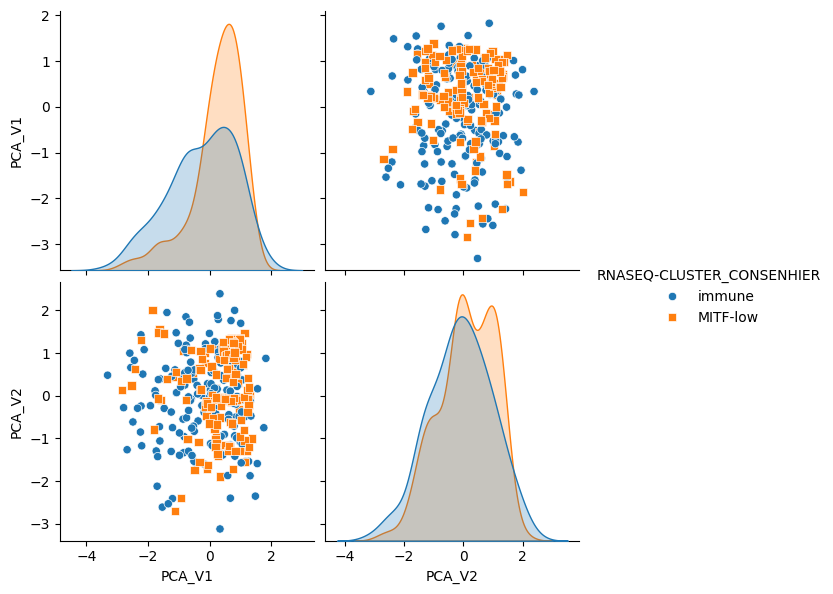

In [3]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

#Transform the initial dataset to be represented by only 2 variables
n_components = 2
pca = PCA(n_components=n_components)
X_2D = pca.fit_transform(X)

#The range of each variable is transformed to [0, 1].
st = StandardScaler()
X_2D = st.fit_transform(X_2D)

#We transfomr the dataset to a data_frame structure (pandas) to facilite the graphical representation
df = pd.DataFrame(X_2D, columns = ['PCA_V1','PCA_V2'])
df = df.join(y)

#We show on a scatterplot the new 2D set, together with the density functions
sns.pairplot(df, hue='RNASEQ-CLUSTER_CONSENHIER', markers=["o", "s"], height=3);

For simplicity, *hold-out validation* will be applied by default for the examples included in this NoteBook. For more details about this, see Module 3 (**Data science and machine learning**).

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

y_int = pd.get_dummies(y).iloc[:,0]
X_2D_train, X_2D_test, y_2D_train, y_2D_test = train_test_split(X_2D, y_int, random_state=42)

print("Number of training instances: {}; y test: {}".format(len(X_train),len(X_test)))

Number of training instances: 252; y test: 84


## **2. SUPPORT VECTOR MACHINES (SVM)**

**SVM** models are one of the tools of choice for many data scientists. The reason for this is because they achieve high accuracy levels, even for complex problems, while using relatively little computing power. Additionally, they can be used for both regression and classification tasks, although they are most relevant in the latter.

This section begins with a complete introduction to the main characteristics and operation of SVMs. We then demonstrate how to use this classification paradigm through *scikit-learn*. Finally, we will briefly list the pros and cons of this type of model.




### **2.1 Introduction to support vector machines**

The goal of an SVM is to find a hyperplane of separation between the instances of two classes. A hyperplane is exactly the same type of discriminant function as used for other linear classifiers such as *logistic regression*. As you may remember, the hyperplane equation is simply a scalar product of a vector of input variables $x$ with a vector of weights, or the importance of the variables $w$ $\|x,w\|$:

\begin{equation}
\hat{y}(x,w) = w_0 + w_1 \cdot x_1 + \ldots + w_n \cdot x_n
\end{equation}

SVMs are different with respect to other linear separation methods because the one with the highest margin is chosen from among all the possible hyperplanes that divide the instances into two parts. This margin is calculated as the maximum distance between the boundary instances, as shown in the figure below:

![Margin computed by an SVM](https://imgur.com/bNN5IAP.png)

The name of this learning technique is derived from the instances upon which the decision boundary ‘rests’—the points closest to the hyperplane—and directly influence the SVM orientation required to reach the aforementioned maximum margin. Different mechanisms or mathematical approximations are available to help find the optimal hyperplane orientation. Importantly, these mainly depend on the distance of the misclassified instances on the other side of the ‘linear boundary’. Thus, the most important parameter in a SVM is the **cost**, denoted as `C`:

- A low `C` value would accept the occurrence of some classification errors, thereby slightly lowering the prediction quality obtained for the training set but usually producing better generalization in the test set.
- A high `C` value allows a better model fit to the training data but implies a higher risk of overlearnin.

Despite the above, a simple hyperplane is not the right solution when the classes represented in the problem are not linearly separable (the problem is difficult), or when there is a lot of noise in the data (i.e., some errors were made when capturing the information about the problem). However, SVMs are a tool that achieve strong predictive results, even for complex problems.

The solution used to overcome these issues is known as the *kernel trick*. This basically consists of assigning the data to a more complex space with non-linear variables and then using the linear SVM classifier (the basic approach described above) in this new space. For example, by adding a new dimension or variable, we can achieve suitable data separation, as shown in the figure below:

![non-linear data transformation to build a linear borderline](https://i.imgur.com/AnUGAb7.png)

To change the data space of the input variables, so-called *kernel functions* (hence the name *kernel trick*) are used, which increase the dimensionality of the problem (by ‘adding new variables’), thereby completing non-linear mathematical transformations. The two most common examples of these types of kernel functions are

- The polynomial function: $K(x,w) = \langle x, w \rangle ^d$, which transforms the linear summation of the products of weights $w_i$ and variables $x_i$ into a higher degree (2, 3, etc.) polynomial. Thus, instead of a hyperplane or ‘straight line’ we will obtain more complex data division
- The *Radial Base Function* (RBF): $K(x,w) = e^{-\frac{\|x-w\|^2}{2\cdot\sigma}}$, which can represent non-linear discriminant functions as ‘circular’ areas.


There is no universal answer as to which type of kernel to use in each context because this answer will very much depend on the characteristics of the problem. Polynomial kernels are simpler and less prone to overlearning when the degree (d) is small (less than or equal to 5). However, RBF kernels are generally more successful because they find more complex discriminant functions that allow for better class separation. A parameter known as ‘gamma’ (γ), which controls how the transformation of the data set is performed, is used for this purpose and therefore, RBF will tend to overlearn with high γ values.

Finding the ideal combination between the `C` parameters and kernel parameters `d` or γ is a complicated task. Hyperparameter tuning procedures such as [Grid Search](https://scikit-learn.org/stable/modules/grid_search.html) are often used for this purpose, however the details of these methods are beyond the scope of this current course.


### **2.2 The implementation of support vector machines in Python**

Following the format of all the learning methods in *scikit-learn*, to execute an SVM it is sufficient to create a `SVC` class object and adjust it using the sets `X` and `y`, as shown below:

In [5]:
from sklearn import svm
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

clf = svm.SVC(probability=True) #parameter so that AUC can be calculated
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test,y_pred)
print("The accuracy percentage obtained is",acc*100)

The accuracy percentage obtained is 83.33333333333334


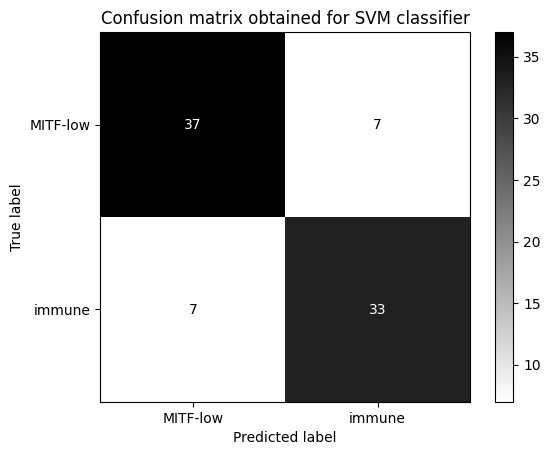

              precision    recall  f1-score   support

    MITF-low       0.84      0.84      0.84        44
      immune       0.82      0.82      0.82        40

    accuracy                           0.83        84
   macro avg       0.83      0.83      0.83        84
weighted avg       0.83      0.83      0.83        84

The F1 measure for classifier SVC is 0.8250
The AUC measure for classifier SVC is 0.9278


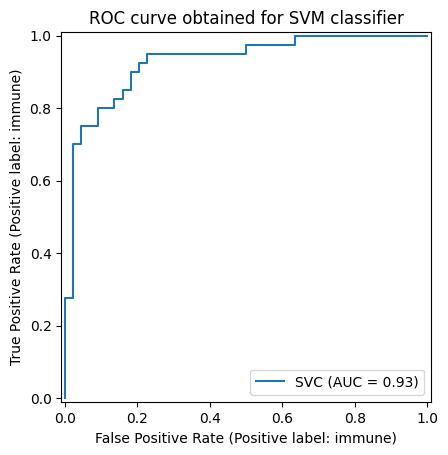

In [6]:
from sklearn import metrics
import matplotlib.pyplot as plt

metrics.ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test,cmap='binary')
plt.title("Confusion matrix obtained for SVM classifier")
plt.show()

print(metrics.classification_report(y_test,y_pred))

f1 = metrics.f1_score(y_test,y_pred,pos_label='immune')
print("The F1 measure for classifier %s is %.4f"%(clf.__class__.__name__,f1))

y_probs = clf.predict_proba(X_test)
auc = metrics.roc_auc_score(y_test, y_probs[:,1])
print("The AUC measure for classifier %s is %.4f"%(clf.__class__.__name__,auc))
metrics.RocCurveDisplay.from_estimator(clf, X_test, y_test)
plt.title("ROC curve obtained for SVM classifier")
plt.show()

We must emphasize the special importance of the configuration parameters in the SVM algorithm; the following describes the main ones and their specific notation in *Python*:

- `C`: a real value (`float`) indicating the regularization or cost parameter. C must always be positive and larger values are used to seek a better fit to the training data, with the default being 1.0.
- `kernel`: a value specifying the type of kernel used in the algorithm; choose from {`linear`, `poly`, `rbf`, `sigmoid`, or `precomputed`}, with the default being `rbf`.
- `degree`: an integer value (`int`) whose default value is 3 indicating the degree of the polynomial (`poly`) kernel, so that it has no used for the remaining kernel functions. This parameter was previously mentioned above as `d`.
- `gamma`: is a value chosen from between {`scale` and `auto`} or may be a real number (`float`); it is the kernel coefficient for the `rbf`, `poly`, and `sigmoid` cases, with the `scale` default being `1/(n_features * X.var()`) and the `auto` default being `1/n_features`.

Finally, the borders generated according to different kernel and parameter values are shown. At this point, we must note several factors, as described below:

1. The boundaries represented when using the `rbf` kernel tend to be elliptic, while for the polynomial (`poly`) they are usually linear.
2. By increasing the parameter `C` (SVM with RBF), the boundaries usually fall closer to the training points.
3. By increasing the `degree` (d) parameter (polynomial SVM), the boundaries become much more complex.
4. The graphical representation of the discriminant functions sometimes does not seem to coincide with the position of the instances in the dataset. This is normal because, to find a linear discriminant function separating the data, the boundary is actually displayed directly on the newly constructed variables.

Because SVMs involve many computations, it may take a few seconds for the results to display

<Figure size 1500x1200 with 0 Axes>

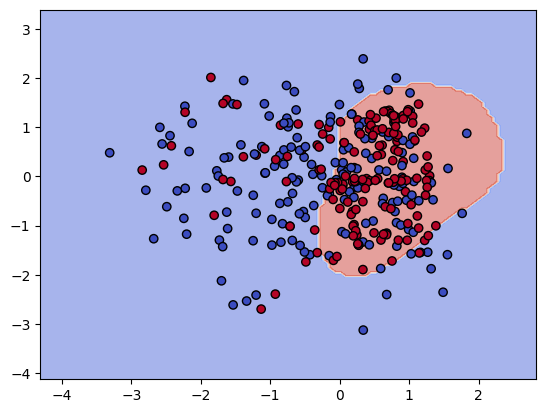

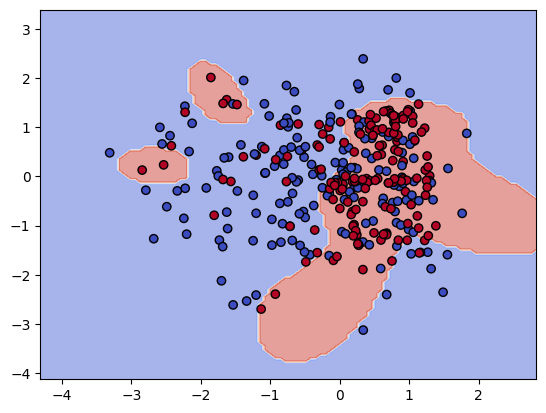

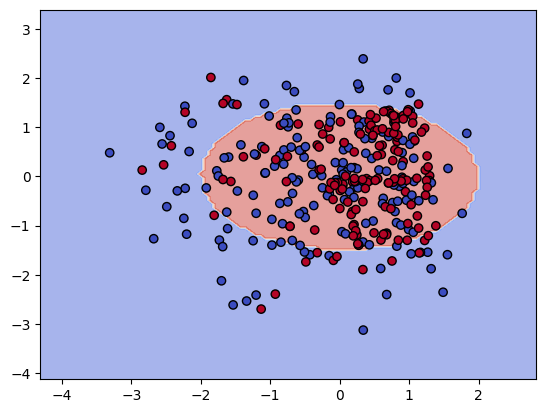

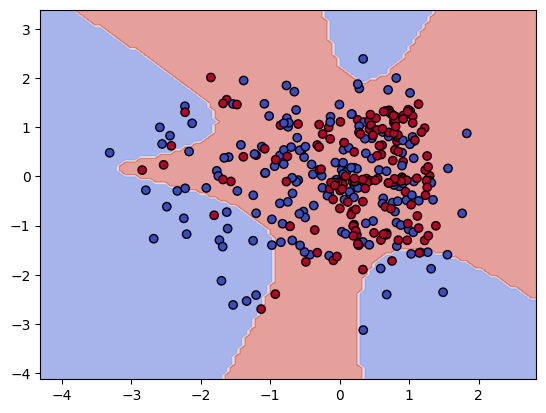

In [7]:
#A special library for 2D painting is imported.
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.gridspec as gridspec
import itertools

#To instantiate and train SVM classifiers with the 2D data
svm_rbf_1 = svm.SVC(kernel='rbf',C=1)
svm_rbf_100 = svm.SVC(kernel='rbf',C=100)
svm_poly_2 = svm.SVC(kernel='poly',degree=2,C=1)
svm_poly_5 = svm.SVC(kernel='poly',degree=5,C=1)
svms = [svm_rbf_1, svm_rbf_100, svm_poly_2, svm_poly_5] #lista

#Parameters to be used to display the figure
scatter_kwargs = {'s': 120, 'edgecolor': None, 'alpha': 0.7}
contourf_kwargs = {'alpha': 0.2}
scatter_highlight_kwargs = {'s': 120, 'label': 'Test data', 'alpha': 0.7}

#Necessary to plot all 4 graphics together
gs = gridspec.GridSpec(2, 2)
fig = plt.figure(figsize=(15,12))

identificador = ['SVM RBF C1', 'SVM RBF C100', 'SVM Poly D2', 'SVM Poly D5']
for clf, etq, grd in zip(svms, identificador, itertools.product([0, 1], repeat=2)):
    clf.fit(X_2D_train, y_2D_train)
    score = clf.score(X_2D_test,y_2D_test)
    disp = DecisionBoundaryDisplay.from_estimator(clf, X_2D,
                                              response_method="predict",
                                              alpha=0.5,
                                              cmap=plt.cm.coolwarm)

    disp.ax_.scatter(X_2D[:, 0], X_2D[:, 1],
                    c=y_int, edgecolor="k",
                    cmap=plt.cm.coolwarm)

plt.show()

### **2.3 Support vector machine characteristics**

Like all other classification paradigms, SVMs have different properties that make them preferable in certain scenarios or that may complicate their proper use in others.

First, the main advantages of SVMs are as follows.

- They are effective for *high-dimensionality* problems; they obtain good solutions even when there are many input variables.
- SVMs behave well when the *number of variables is larger than the number of instances*. Indeed, this is of vital importance when dealing with bioinformatics problems.
- They are *memory efficient* because the model is based solely on storing the ‘support vectors’ found during training.
- SVMs are *versatile*: they adapt well to different problems by configuring the most appropriate kernel function in each study case.

However, the disadvantages of SVMs include the points detailed below.

- SVM models are *difficult to parameterize*: their behavior is strongly dependent on the parameters selected for the `cost` and `kernel` functions. Thus, ‘hyperparametrization’ must be performed to try to identify the optimal values, which itself cannot guarantee the best results.
- Like other linear classifiers, SVMs are not adapted to non-numeric characteristics and their use requires the *treatment of nominal data*. Thus, a transformation must be applied that generates new variables through binary coding.
- They are *exclusively used for binary problems*. By default, SVMs do not allow classification in problems with more than two classes, meaning that they have to resort to ‘divide-and-conquer’ strategies. This involves transforming the problem into multiple subproblems of binary classes.
- Their *calculation of output probabilities is inaccurate*. When probability or confidence values must be obtained for a problem output, for example to compute the AUC metric, the reliability of the values obtained with a SVM is usually low.

## **3. ARTIFICIAL NEURAL NETWORKS AND DEEP LEARNING**

Artificial Neural Networks (ANNs) are inspired by the way the human brain works. Very simplistically, imagine an ANN as a network of small units called neurons that work together to solve problems.

In ANNs, neurons are organized according to different layers. The first layers are usually for receiving information, such as input data (variables), and the last layers provide the answer or result (e.g. class label). The interesting thing happens in between, in called as the hidden layers, as will be studied later. As the number of hidden layers increases, we enter what is called "Deep Learning" (DL). DL allows the network to learn and represent more complex and abstract features, especially for problems with unstructured data such as text, images or signals.

In the rest of this section, the concept of neuron and layer will be introduced in more detail, and it will be described how the training of a model based on ANNs is performed. Subsequently, it will be presented how to use this tool with Python (via `scikit-learn`). Then, the characteristics corresponding to its use will be indicated. Finally, some notes on the relationship between ANNs and DL will be given.  

### 3.1 What is an Artificial Neural Network?

#### 3.1.1 The Basic Neuron: the Perceptron

It all started in the early 1940s with the invention of what would be called the basic processing unit in a neural network: the **Perceptron**. Mathematically, the perceptron takes a set of inputs ($i_1,i_2,\ldots,i_n$), applies weights to those inputs, and produces an output ($o$). This output is obtained by applying an activation function to the weighted sum of inputs and weights. The activation function can be as simple as a step function, which fires if the weighted sum exceeds a certain threshold.

![Perceptron Representation (taken from Wikipedia)](https://upload.wikimedia.org/wikipedia/commons/thumb/3/31/Perceptron.svg/706px-Perceptron.svg.png)

If this structure reminds you of something, you're correct: a perceptron can be considered as a type of basic linear classifier (similar to those seen in Module 5.2). Like linear classifiers, its capacity is limited when dealing with more complex data that is not linearly separable. This is where ANNs come into play by increasing the number of layers and neurons used.

#### 3.1.2 The Hidden Layers

A neural network can be defined as a collection of perceptrons organized in layers (groups of neurons). In addition to the input layer (whose number of neurons matches the number of inputs) and the output layer (usually consisting of a single neuron for binary output), there can be intermediate layers known as **hidden layers**.

The hidden layer is where the magic happens in a neural network. Each node or "neuron" in this layer takes the outputs of perceptrons in the previous layer (which can be directly the input or another hidden layer), applies its weights, aggregates the results, and passes the result through what is called an **activation function**. This allows the network to learn and capture complex (non-linear) features and patterns in the data. In other words, these neurons represent intermediate features or abstractions of the inputs.

In this context, we would be considering what is known as the Multi-Layer Perceptron or **MLP**. The figure below illustrates an MLP with three layers:

- The first layer is the input layer with 3 neurons, which correlates with a problem represented by 3 descriptive variables.
- The second layer is the hidden layer, with a total of 4 neurons.
- The last layer is the output layer, which in this case has two neurons and can encode up to 4 different values.

It's important to note that all neurons in one layer are connected to all neurons in the next layer, following a scheme called **fully connected**.

![Example of an ANN with a single hidden layer](https://upload.wikimedia.org/wikipedia/commons/thumb/4/46/Colored_neural_network.svg/480px-Colored_neural_network.svg.png)

#### 3.1.3 Relationship with the Activation Function

As mentioned earlier, each neuron in the hidden layer applies a mathematical function to its result. This activation function determines whether the neuron should "fire" (send a signal) or not, based on the weighted sum of its inputs. Some of the most common activation functions include:

- **ReLU (Rectified Linear Unit)**: $f(x) = \max(0, x)$
- **Sigmoid**: $f(x) = \frac{1}{1 + e^{(-x)}}$
- **Tanh (Hyperbolic Tangent)**: $f(x) = \frac{e^x - e^{(-x)}}{e^x + e^{(-x)}}$

The choice of the activation function can influence how the network learns and behaves. For example, the `ReLU` function is commonly used because it's efficient and avoids certain issues in learning. The `sigmoid` function is useful for binary classification problems, while the `tanh` function is helpful in situations where inputs have both negative and positive values.

### 3.2 Training through Backpropagation: A Learning Journey

Training an ANN is a fascinating process that resembles human learning based on examples. Imagine an ANN as a student who improves their performance through constant practice. Specifically, what gets adjusted in the structure of an ANN are the values of the weights in the connections between neurons. These are called the **parameters of the network**. The more parameters, the more complex the network becomes for learning more challenging problems, but at a higher computational cost.

Here, we explore how this training process works, emphasizing simple terms and key concepts.

#### 3.2.1 Step 1: Initialization and Random Weights
We begin with an empty neural network (only the structure of layers). Just like a student on their first day of class, it doesn't know anything. So, the weights of connections between neurons are initialized randomly.

#### 3.2.2 Step 2: Feed Forward Propagation
Like students, the ANN receives training data (the complete dataset). The information propagates through the network from the input layer to the output layer. Each neuron performs mathematical calculations based on input data and the weights of connections, through the well-known activation function. These calculations produce a response from the network (decoded value of the output neuron(s)), which is initially the predicted class label.

#### 3.2.3 Step 3: Comparison with the Desired Response
The network compares its response with the desired response (the correct answer), much like a student comparing their answers on a test to the correct answers. This comparison generates an "error," which measures how close or far the network is from the correct response. This error is measured by what is known as a loss function.

#### 3.2.4 Step 4: Error Backpropagation
Here's where "feedback" comes into play. The network adjusts its connections (weights) based on the error. If the response is incorrect, the network modifies its connections so that it gets closer to the desired response next time. This process is called "backpropagation" and resembles the feedback-based learning students use to improve.

#### 3.2.5 Learning Rate
Imagine the student having a learning rate, which determines how much they change their answers based on their errors. If the learning rate is high, they learn quickly but might be unstable. If it's low, they learn slowly but with greater accuracy.

#### 3.2.6 Iteration and Constant Practice
This process is repeated many times. The network keeps seeing examples, making mistakes, and adjusting. Input examples are fed to the network in batches, and this process is repeated with multiple "passes" through the dataset. It's like a student practicing the same exercises over and over again to improve their skills.

With each training cycle, the ANN becomes more and more competent, much like a student becoming an expert in a subject. Through backpropagation, learning rate, and regularization, the neural network learns to effectively solve problems. This is where we can identify the so-called "network convergence," meaning its effectiveness in correctly adjusting to the problem in each cycle.

### 3.3 Calculating the Output of a Neural Network and Extending to Multiple Classes

Up to this point, we have mainly discussed neural networks with a single output neuron, which can encode a binary value $\{ 0,1 \}$ depending on whether it exceeds a certain activation threshold, typically using the sigmoid function. This makes them ideal for dichotomous decision problems, such as diagnosing diseases as present or absent.

However, in the real world, we often face more complex problems where responses aren't simply "yes" or "no" but can belong to multiple categories.

In such cases, we use a higher number of neurons along with special activation functions to extend the output of a neural network to multiple classes. A common function for this is the **Softmax** function. This function calculates the probability that a sample belongs to each class, and the sum of these probabilities is equal to 1.

So, the network's output is extended to accommodate different classes, and activation functions like `Softmax` enable the assignment of probabilities to each class. This is the magic that allows neural networks to handle multi-class problems, such as recognizing handwritten digits or classifying images into various categories.

### 3.2 Implementation of neural networks in Python

This section gives the details necessary to build a model based on the multi-layer perceptron (`MLPClassifier`), found in the `neural_network` library.

In this example, a neural network with a single hidden layer of 10 neurons will be created, and the network will be trained for 1000 iterations. These values can be adjusted according to the needs of each problem, as will be described below.

In [8]:
from sklearn.neural_network import MLPClassifier

# We create and train the neural network (random_state is used to give the same results every time it is run)
clf = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

#we test its predictive quality
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test,y_pred)
print("The accuracy obtained is",acc*100)


The accuracy obtained is 80.95238095238095


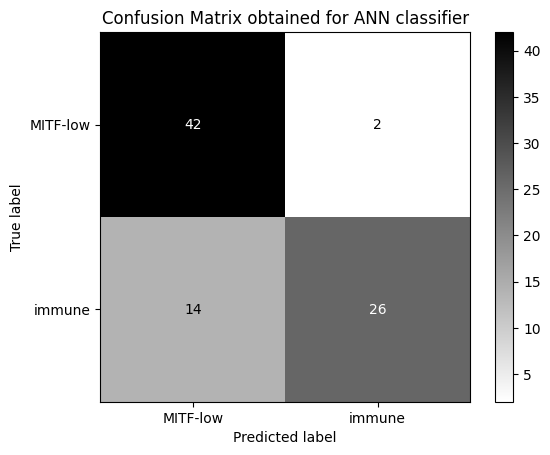

              precision    recall  f1-score   support

    MITF-low       0.75      0.95      0.84        44
      immune       0.93      0.65      0.76        40

    accuracy                           0.81        84
   macro avg       0.84      0.80      0.80        84
weighted avg       0.84      0.81      0.80        84

The F1 measurement for classifier MLPClassifier is 0.7647
The AUC measure for classifier MLPClassifier is 0.8330


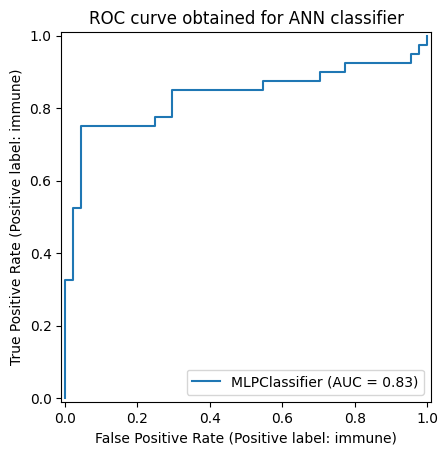

In [9]:
metrics.ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test,cmap='binary')
plt.title("Confusion Matrix obtained for ANN classifier")
plt.show()

print(metrics.classification_report(y_test,y_pred))

f1 = metrics.f1_score(y_test,y_pred,pos_label='immune')
print("The F1 measurement for classifier %s is %.4f"%(clf.__class__.__name__,f1))

y_probs = clf.predict_proba(X_test)
auc = metrics.roc_auc_score(y_test, y_probs[:,1])
print("The AUC measure for classifier %s is %.4f"%(clf.__class__.__name__,auc))
metrics.RocCurveDisplay.from_estimator(clf, X_test, y_test)
plt.title("ROC curve obtained for ANN classifier")
plt.show()

<Figure size 1200x900 with 0 Axes>

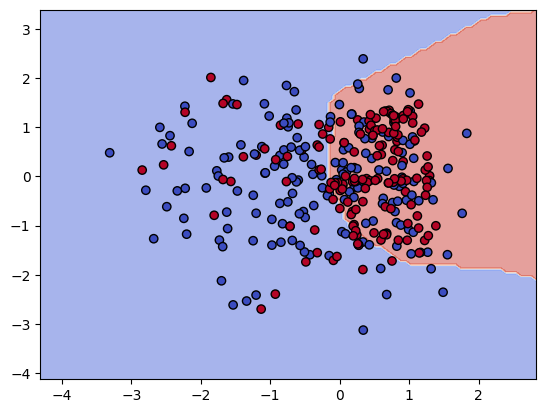

In [10]:
#We create and traing the classifier with the 2D dataset
clf = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)
clf.fit(X_2D_train, y_2D_train)
score = clf.score(X_2D_test,y_2D_test)

fig = plt.figure(figsize=(12,9))
fig = DecisionBoundaryDisplay.from_estimator(clf, X_2D,
                                              response_method="predict",
                                              alpha=0.5,
                                              cmap=plt.cm.coolwarm)

fig.ax_.scatter(X_2D[:, 0], X_2D[:, 1],
                 c=y_int, edgecolor="k",
                 cmap=plt.cm.coolwarm)

plt.show()

As with SVMs, the hyperparameters of ANNs have a significant influence on the behavior and predictive ability of the model, i.e. how well or poorly it will fit the data to faithfully reproduce the information of the problem. Thus, finding a good balance between under-training and over-training is quite complex, and `GridSearch` type optimization procedures are often used as in the case of SVMs.

When using an ANN, there are a large number of configuration variables (hyperparameters) to adjust, so only the most important ones are shown below:

- `hidden_layer_sizes`: This is a setting that represents the number of neurons in each hidden layer of a neural network. For example, if it is desired to apply a single hidden layer with 100 neurons, it would be configured as `hidden_layer_sizes=(100,)` (this is the default value).

- `activation`: As stated above, the activation function is an important part of a neural network. It is the mathematical function that determines whether a neuron should fire or not. There are several common options, such as ``identity'`, which does nothing (i.e., neither activates nor deactivates the neuron), ``logistic'`, which uses the sigmoid function, ``tanh'`, which uses the hyperbolic tangent, and ``relu'`, which is the rectified linear unit function (which is the default).

- `learning_rate_init`: This is the initial learning rate. It controls the size of the steps the network takes when adjusting its weights (default `learning_rate_init=0.001`).

- `max_iter`: This is the maximum number of iterations the network will perform during training. If it does not converge before reaching this number, the training will stop (default `max_iter = 200`).

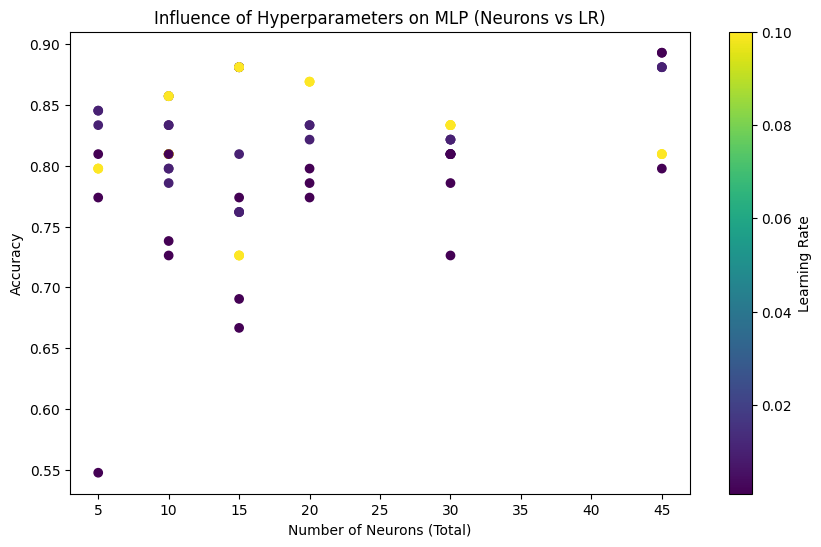

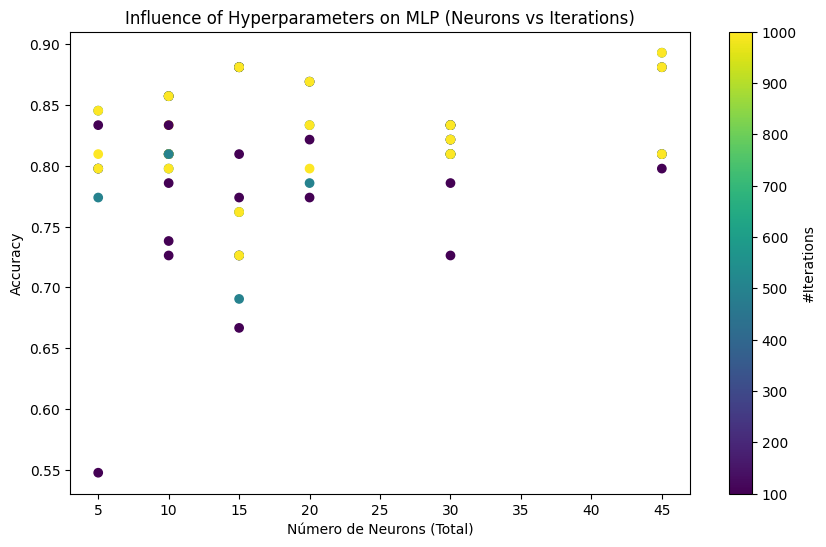

In [11]:
#Let's see the influence of some of these parameters on the results (it will take a few seconds to execute)
import numpy as np

# Parameters we are going to vary
num_layers = [1, 2, 3] # num_neurons = [5, 10, 15] # num_neurons = [5, 10, 15
num_neurons = [5, 10, 15]
learning_rates = [0.001, 0.01, 0.1]
max_iterations = [100, 500, 1000]

# We will store the results of the accuracy
accuracies = []

# Iterate through different configurations
for layers in num_layers:
    for neurons in num_neurons:
        for rate in learning_rates:
            for iterations in max_iterations:
                clf = MLPClassifier(hidden_layer_sizes=(neurons,) * layers, max_iter=iterations, learning_rate_init=rate, random_state=42)
                clf.fit(X_train, y_train)
                accuracy = clf.score(X_test, y_test)
                accuracies.append((layers, neurons, rate, iterations, accuracy))

# We extract the accuracy values
accuracies = np.array(accuracies)

# Display the results graphically
plt.figure(figsize=(10, 6))
plt.scatter(accuracies[:, 0] * accuracies[:, 1], accuracies[:, 4], c=accuracies[:, 2], cmap='viridis')
plt.xlabel('Number of Neurons (Total)')
plt.ylabel('Accuracy')
plt.title('Influence of Hyperparameters on MLP (Neurons vs LR)')
plt.colorbar(label='Learning Rate')
plt.show()

# Show the results graphically
plt.figure(figsize=(10, 6))
plt.scatter(accuracies[:, 0] * accuracies[:, 1], accuracies[:, 4], c=accuracies[:, 3], cmap='viridis')
plt.xlabel('Número de Neurons (Total)')
plt.ylabel('Accuracy')
plt.title('Influence of Hyperparameters on MLP (Neurons vs Iterations)')
plt.colorbar(label='#Iterations')
plt.show()

### 3.3 Characteristics of Artificial Neural Networks

ANNs have their own advantages and disadvantages that make them suitable for different situations in biology and other disciplines. The following are a series of properties of interest, distinguishing between potentially positive and negative aspects.

#### 3.3.1 Advantages of ANNs

1. **Ability to Learn Nonlinear Models:** One of the key advantages of ANNs is their ability to learn and model nonlinear relationships in data. This makes them effective for classification tasks where decision boundaries are complex or irregular.

2. **Flexibility in Classification and Regression Tasks:** ANNs can be applied to a variety of tasks, from classifying plant species to predicting growth rates. They are versatile and can adapt to different types of problems.

3. **Ability to Extract Relevant Features:** Neural networks can learn useful features directly from the data, reducing the need for manual feature extraction.

4. **Handling Noisy Data:** Neural networks are robust and can handle noisy or erroneous data, which is common in real-world applications.

5. **Application in Various Domains and Multimodal Problems:** Neural networks have been successfully used in a wide range of domains, from speech recognition and computer vision to biology and finance. Moreover, for problems involving multiple input modes (e.g., images and text), neural networks can effectively merge and model these modalities.

6. **Real-Time Adaptation:** Neural networks can continuously learn and adjust as new data arrives. This makes them suitable for applications where patterns change over time (continuous learning).

#### 3.3.2 Disadvantages of ANNs

1. **Non-Convex Loss Function:** ANNs with hidden layers have a loss function that is non-convex. Mathematically, this means there are multiple local minima in this function. As a result, different random weight initializations can lead to different levels of validation accuracy. This results in relatively unstable behavior and a strong dependence on the choice of the starting seed.

2. **Necessary Hyperparameter Tuning:** To achieve good results with ANNs, it's necessary to adjust various hyperparameters, such as the number of neurons in hidden layers and the number of iterations. Finding the optimal configuration may require an exhaustive search, known as hyperparameter tuning.

3. **Sensitivity to Feature Scale:** ANNs are sensitive to feature scaling. Therefore, it's strongly recommended to scale the data before using an ANN. The appropriate scaling method may vary depending on the dataset and should be applied to both training and test data for accurate results. Any scaling technique (e.g., `Min-Max` or `StandardScaler`) can be useful in this case.

4. **Issues with Non-Numeric Data:** Like other machine learning models, ANNs are not designed to handle non-numeric features such as names or labels (categorical). These features generally require transformation before using an ANN (e.g., through one-hot encoding).

5. **Requires Large Sample Size:** Although ANNs are capable of learning complex patterns, their performance improves with a large dataset. In cases with very small datasets, they may not be the best choice.

6. **Potentially Slow on Large Datasets:** Compared to other algorithms, ANNs can be relatively slow on very large datasets, especially when increasing the number of iterations needed for proper convergence (with a low learning rate).

## **4. ENSEMBLES AND RANDOM FOREST**

The most widely used algorithms in data science may be those based on multiple classifiers, which are generally known as ‘ensembles’.

In this section, we introduce what this type of learning system involves. We will subsequently focus on one of the best-known approaches to this type of method: the Random Forest algorithm. Finally, we will point out some of the advantages and disadvantages of this paradigm.



## **4.1 Introduction to the ensemble paradigm**

So far, we have constructed a single model from the problem data which has allowed predictions of varying accuracy to be made about the test set. However, in everyday data sciences work, we usually rely on the judgement of different sources when making decisions. Indeed, aggregating or combining the ‘opinions’ of a group of experts seems to be key to increasing confidence in a particular prediction. For this scenario to be truly valid, we must understand two very important premises:

- To help guarantee adequate quality of the answer, decisions/predictions must be made from sources or experts with a certain degree of credibility.
- These experts or sources should be diverse to promote a certain level of objectivity.

Ultimately, being able to rely on the opinion of specialists who present complementary points of view will help us to increase the quality and reliability of the decisions we make. This premise also has a direct application in machine learning algorithms, referred to as ‘ensemble models’. A relatively large number of classifiers are constructed in this family of algorithms, by using two approaches, as follows.

- “*Bagging*”: Refers to using a different subset of the training data, in this case, `M` classifiers are trained independently.
- “*Boosting*”: Using weights or costs for examples that are more difficult to correctly identify. In this case, `M` iterations are performed, each one generating a classifier dependent on the result of the previous stage.

This section of the course focuses exclusively on the first of these two strategies: **bagging**.


### **4.2 Random Forest: fundamentals and implementation in Python**

To properly understand the Random Forest algorithm, we must first define the bagging methodology in detail. If you have $X$ data set of size $N$, you could generate a new set with replacement data by randomly taking $N$ instances. If this procedure is repeated $M$ times, enough sets are obtained so that their ‘combination’ represents the original distribution of the data.

In the case of the supervised learning task, $M$ new training sets will be created, which will all be of the original size, but with some of the instances repeated in each new set. This allows $M$ independent classifiers to be learned, each specializing in the instances used in their specific training.

Given that each model is relatively independent of the others, and each may generate differing output values, the main question that arises at this point is how can we unify the global model response? In the case of *classification*, the most common way to achieve this is to use majority voting. Random Forest is a learning algorithm used interchangeably either for classification or regression and is based on the aforementioned bagging principle. In this case, the name ‘forest’ allows us to deduce which family of models is trained on each subsample of the training set: **decision trees**.

However, this algorithm adds a new component to the bagging methodology: it also implements selection of input variables in each training subset to obtain dual benefits. On the one hand, it increases the differences between each set and therefore, between each model generated. On the other hand, it reduces the learning time and complexity of each model.

![Example of the working procedure of Random Forest](https://i.imgur.com/QhZMpbv.png)

Returning to the two main characteristics that must be fulfilled for the ensemble methodology, regarding Random Forest:

- The classifiers used are based on decision trees and are therefore, very appropriate for learning.
- The selection of instances, together with the selection of variables, allows the construction of each individual tree to be relatively different from that of the other models which leverage strength in numbers.

As the following example shows, using the Random Forest algorithm in *scikit-learn* is as simple as for any other classifier.

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
acc = accuracy_score(y_test,y_pred)
print("The accuracy percetange obtained by RF is ",acc*100)

The accuracy percetange obtained by RF is  91.66666666666666


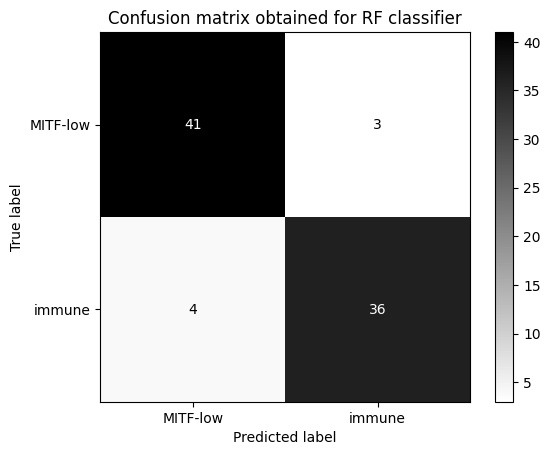

              precision    recall  f1-score   support

    MITF-low       0.91      0.93      0.92        44
      immune       0.92      0.90      0.91        40

    accuracy                           0.92        84
   macro avg       0.92      0.92      0.92        84
weighted avg       0.92      0.92      0.92        84

The F1 measure for classifier RandomForestClassifier is 0.9114
The AUC measure for classifier RandomForestClassifier is 0.9716


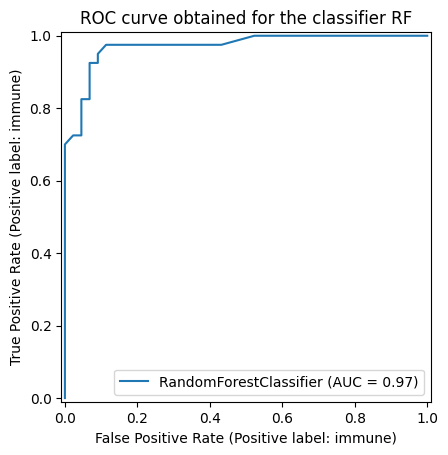

In [13]:
metrics.ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test,cmap='binary')
plt.title("Confusion matrix obtained for RF classifier")
plt.show()

print(metrics.classification_report(y_test,y_pred))

f1 = metrics.f1_score(y_test,y_pred,pos_label="immune")
print("The F1 measure for classifier %s is %.4f"%(rf.__class__.__name__,f1))

y_probs = rf.predict_proba(X_test)
auc = metrics.roc_auc_score(y_test, y_probs[:,1])
print("The AUC measure for classifier %s is %.4f"%(rf.__class__.__name__,auc))
metrics.RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("ROC curve obtained for the classifier RF")
plt.show()

There is a very interesting dual advantage to the implementation of Random Forest in *scikit-learn*:

1. irst, it allows the identification of the most important input variables used to predict the output. To do this, we must consult one of the properties of the model, `feature_importances_` (which determines the weight of each variable), when normalized to reach a sum of 1.
2. Second, the input dataset can be transformed according to the above information, thus simplifying and improving the subsequent learning process. Specifically, the `transform()` method will reduce the dataset, leaving only the selected variables.

An example of how to carry out this process is shown below:

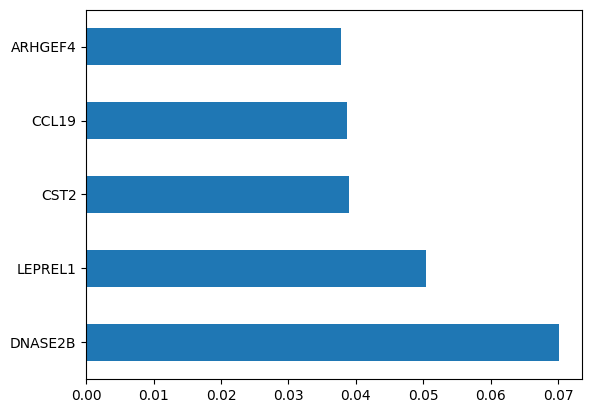


The accuracy with the simplified model at 16 variables is 88.0952


In [14]:
#To perform feature selection, we use the following:
from sklearn.feature_selection import SelectFromModel

#First, we capture the importance ranking values
importance = rf.feature_importances_
#The 5 most important ones are represented
(pd.Series(importance, index=X_train.columns).nlargest(5).plot(kind='barh'))
plt.show()

#Next, the training and test set is transformed.
#For this purpose, only the most important variables according to RF will be used.
fs = SelectFromModel(rf,prefit=True) #instruction defining the variables
X_train_fs = fs.transform(X_train) #Train set transformation
X_test_fs = fs.transform(X_test) #Transformation of the test set

rf_fs = RandomForestClassifier(random_state=42) #Re-train specific model with fewer variables
rf_fs.fit(X_train_fs, y_train)

y_pred = rf_fs.predict(X_test_fs)
acc = accuracy_score(y_test,y_pred)
print()
print("The accuracy with the simplified model at %d variables is %.4f"%(X_test_fs.shape[1],acc*100))

The Random Forest algorithm has three main parameters:

- `n_estimators`: an integer value (`int`) indicating the number of decision trees used, with the default being 100.
- `max_depth`: an integer value (`int`) that sets the maximum depth of each tree with the default set to “none”. If no value is set, the nodes are expanded until all the leaves are pure or until they all contain less than `min_samples_split` instances.
- `max_features`: a value chosen from {`auto`, `sqrt`, or `log2`} or an integer or real value (`int` or `float`). This refers to the number of variables to consider when looking for the best split, with the default being `auto` which is equivalent to `sqrt` or the square root of the number of variables.

In general, the preference is for a high number of trees (between 100 and 500) with a large depth (leaving the default `none` setting) also with the default number of variables. However, we must consider that increasing these two parameters implies a higher computational cost, perhaps unnecessarily lengthening the training time. Therefore, it is always advisable to validate and adjust the parameter values independently for each case of study.

The following example shows the decision boundary obtained by Random Forest with the default parameters determined by scikit-learn. Note that in this problem (which was transformed into two variables only), Random Forest’s advantage in terms of diversity is lost while its predictive power tends to be reduced.

<Figure size 1200x900 with 0 Axes>

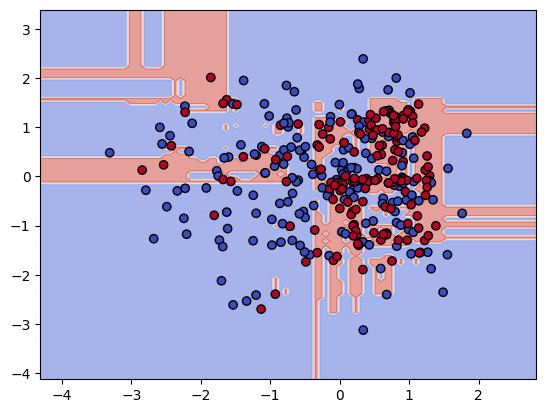

In [15]:
from sklearn.inspection import DecisionBoundaryDisplay

#We create and train the classifier with 2D data.
clf = RandomForestClassifier(random_state=42)
clf.fit(X_2D_train, y_2D_train)
score = clf.score(X_2D_test,y_2D_test)

fig = plt.figure(figsize=(12,9))
disp = DecisionBoundaryDisplay.from_estimator(clf, X_2D,
                                              response_method="predict",
                                              alpha=0.5,
                                              cmap=plt.cm.coolwarm)

# Proyectamos encima los puntos del conjunto de datos
disp.ax_.scatter(X_2D[:, 0], X_2D[:, 1],
                 c=y_int, edgecolor="k",
                 cmap=plt.cm.coolwarm)

plt.show()

In the following code snippet, we can observe the structure of one of the trees contained within Random Forest:

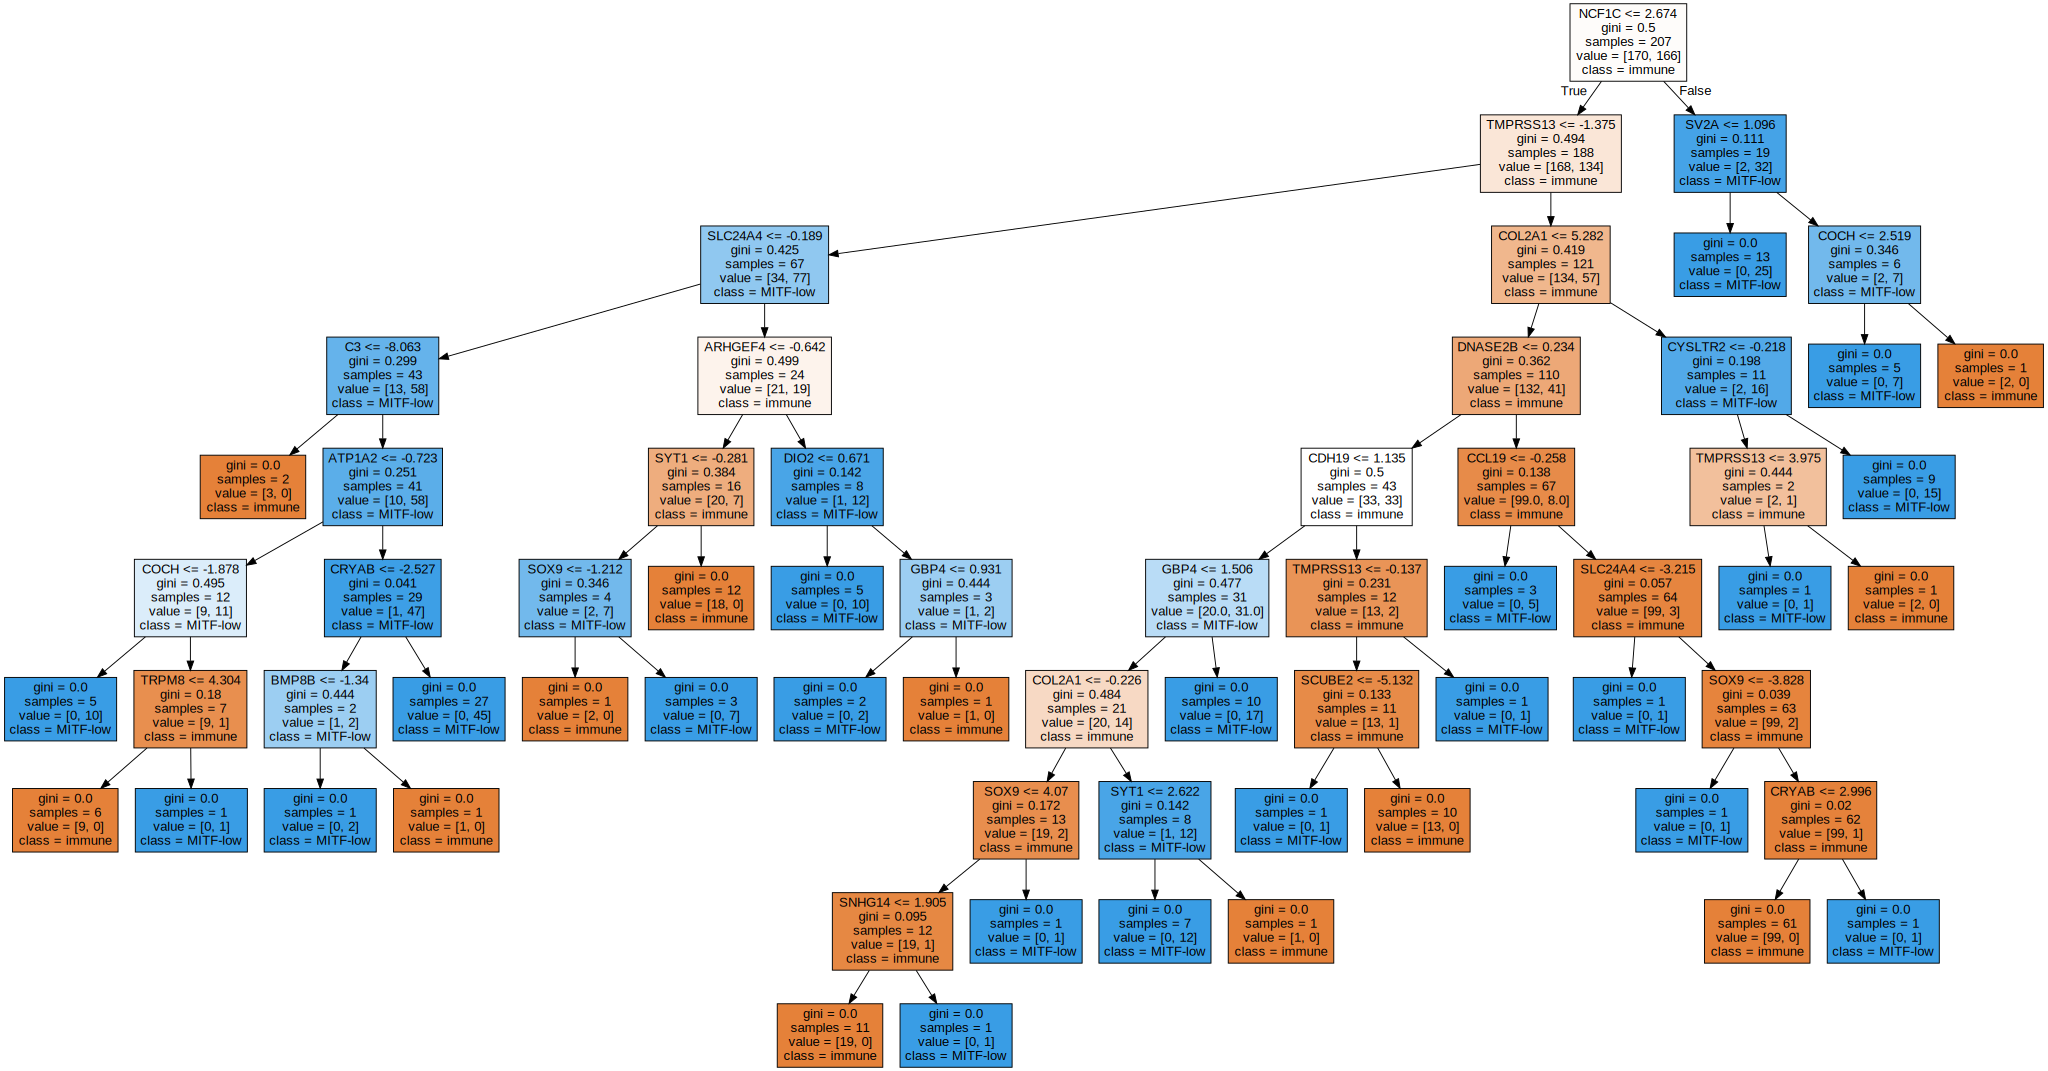

In [16]:
#Libraries needed for better visualisation
from sklearn import tree
from graphviz import Source

rf_full = RandomForestClassifier()
rf_full.fit(X, y)
dt = rf_full.estimators_[0]

#tree is plotted:
tree_graph = tree.export_graphviz(dt, out_file=None,
                                  feature_names=X.columns,
                                  class_names=pd.unique(y[y.columns[0]]),
                                  filled = True)
graph = Source(tree_graph)
graph

### **4.3 Characteristics of Random Forest**

As indicated at the beginning of this section, the Random Forest algorithm is perhaps one of the most widely used algorithms for classification tasks, both by expert users and by those new to data analysis. The main reasons for this are associated with the following characteristics of the algorithm:

- As opposed to the behavior of individual decision trees, it is robust against *overfitting*.
- Its parameter settings are fairly simple and intuitive and its predictive ability is good even when using its default values.
- Random Forest works very well when the number of problem inputs is large and for a large amount of data.
- It allows for high-quality variable selection.

However, the Random Forest method also has some negative aspects that must be considered:

- Depending on the parameterization (i.e., the number of trees and the depth), its learning can be slow.
- In contrast to simple decision trees, the global Random Forest model is not directly interpretable by users. The reason is obvious, namely that the global classifier produces many trees which would have to be individually checked.
- Random Forest does not capture possible correlations between the input variables.


## **BIBLIOGRAPHICAL REFERENCES**

-	Han, J., Kamber, M., Pei, J. (2011). Data Mining: Concepts and Techniques. San Francisco, CA, USA: Morgan Kaufmann Publishers. ISBN: 0123814790, 9780123814791
- Scikit-Learn: Supervised Learning https://scikit-learn.org/stable/supervised_learning.html (accessed on 10th February 2022).
- Open Machine Learning Course: Topic 5. Ensembles of algorithms and random forest. Part 1. Bagging https://mlcourse.ai/articles/topic5-part1-bagging/ (accessed on 10th February 2022).
- Open Machine Learning Course: Topic 5. Ensembles of algorithms and random forest. Part 2. Random Forest https://mlcourse.ai/articles/topic5-part2-rf/ (accessed on 10th February 2022).
- Open Machine Learning Course: Topic 5. Ensembles of algorithms and random forest. Part 3. Feature Importances https://mlcourse.ai/articles/topic5-part3-feature-importance/ (accessed on 10th February 2022).

### **Additional references**

-	Alpaydin, E. (2016). Machine Learning: The New AI. MIT Press. ISBN: 9780262529518
-	Witten, I. H., Frank, E., Hall, M. A., Pal, C. J. (2017). Data mining: practical machine learning tools and techniques. Amsterdam; London: Morgan Kaufmann. ISBN: 9780128042915 0128042915
- Towards Data Science: Support Vector Machines(SVM) — An Overview https://towardsdatascience.com/https-medium-com-pupalerushikesh-svm-f4b42800e989 (accessed on 10th February 2022).


<div class="alert alert-block alert-success">
MOOC Machine Learning and Big Data for Bioinformatics (2nd edition)   

http://abierta.ugr.es

![CC](https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc-nd.png)
</div>    